<a href="https://colab.research.google.com/github/MarioDLCruz/PolisemiaV1/blob/main/umapv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

Conectar con google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cargar el csv con la tabla de tokens y sus embeddings

In [ ]:
file_path = '/content/drive/MyDrive/tokens1k.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,token,id_tweet,region,id_vector,vector
0,[CLS],0,Jalisco,0,[ 1.32701714e-02 -1.79053750e-02 -6.18814072e-...
1,Jalisco,0,Jalisco,1,[ 4.20953473e-03 -3.29080522e-02 1.30279278e-...
2,_GEO,0,Jalisco,2,[-1.35559319e-02 -1.35187013e-03 1.71045307e-...
3,_USR,0,Jalisco,3,[-3.58271115e-02 -4.46212329e-02 2.43038628e-...
4,Se,0,Jalisco,4,[ 2.86497883e-02 -2.64977496e-02 1.78820007e-...
...,...,...,...,...,...
30348,##I,999,Mexico_City,19,[ 9.51175019e-03 7.65987625e-03 7.00742528e-...
30349,##f,999,Mexico_City,20,[-6.96010841e-03 -2.21082475e-02 6.97800005e-...
30350,😭,999,Mexico_City,21,[-5.22314981e-02 -7.29229525e-02 -2.57079042e-...
30351,_URL,999,Mexico_City,22,[-1.76484715e-02 -9.14828330e-02 -3.17632803e-...


In [ ]:
reducer = umap.UMAP()

Cambiar campo vector a float

In [ ]:
import numpy as np
import re

def parse_vector(v_str):
    # Elimina los corchetes si existen y divide por espacios
    clean_str = re.sub(r'[\[\]]', '', v_str)
    # Convierte en lista de floats
    return np.fromstring(clean_str, sep=' ')

# Aplica la conversión
df['vector'] = df['vector'].apply(parse_vector)


Normalizando vectores, modificando n_neighbors


In [ ]:
from sklearn.preprocessing import StandardScaler
import umap

X = np.vstack(df['vector'].values)
X/=np.linalg.norm(X, axis=1).reshape(-1, 1)
X.shape
embedding = umap.UMAP(metric="cosine", n_neighbors=3).fit_transform(X)


In [ ]:
np.linalg.norm(X[0])

np.float64(1.0)

In [ ]:
X.shape

(30353, 512)

In [ ]:
embedding.shape

(30353, 2)

In [ ]:
import matplotlib.pyplot as plt

Grafica de Proyección UMAP de vectores de tokens por región

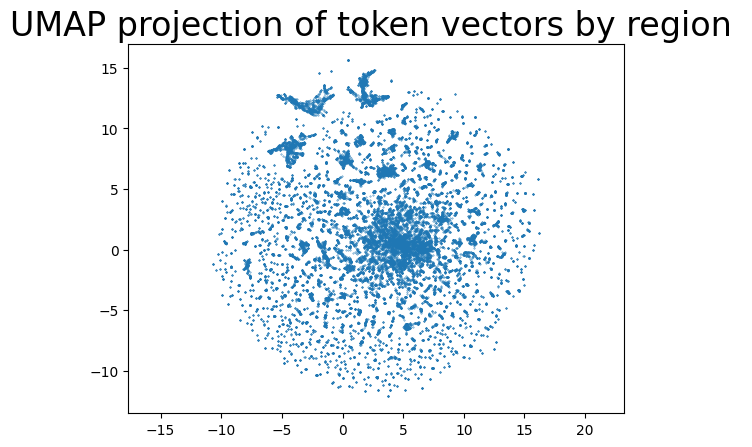

In [ ]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=.1,
    )

    #c=[palette[i] for i in region_indices])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of token vectors by region ', fontsize=24);

In [ ]:
df["x"] = embedding[:, 0]
df["y"] = embedding[:, 1]
df[["token", "region", "x", "y"]]


,token,region,x,y
0,[CLS],Jalisco,-3.832380,12.461946
1,Jalisco,Jalisco,-8.502268,3.205395
2,_GEO,Jalisco,1.921663,-1.079355
3,_USR,Jalisco,7.165409,-0.479093
4,Se,Jalisco,6.037797,-7.252685
...,...,...,...,...
30348,##I,Mexico_City,-6.455865,-5.523135
30349,##f,Mexico_City,2.208125,4.730082
30350,😭,Mexico_City,-4.454748,-1.545403
30351,_URL,Mexico_City,7.141977,-3.412563


In [ ]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="region",
    hover_data=["token", "region", "id_tweet"],
    title="UMAP projection of token vectors by region",
    width=1000,
    height=700
)


fig.update_traces(marker=dict(size=3, opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(legend_title="Región", title_x=0.5)

fig.show()


In [ ]:
from google.colab import files
fig.write_html("umap_tokens.html")
files.download("umap_tokens.html")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Graficacion en 3D

In [ ]:

reducer3d = umap.UMAP(n_components=3, metric="cosine")
embedding_3d = reducer3d.fit_transform(X)

# Guardamos las nuevas dimensiones
df["x"] = embedding_3d[:, 0]
df["y"] = embedding_3d[:, 1]
df["z"] = embedding_3d[:, 2]


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="region",  # O puedes usar "cluster"
    hover_data=["token"],
    opacity=0.6
)
fig.update_traces(marker=dict(size=1))
fig.update_layout(title="UMAP 3D projection of token vectors")
fig.show()
fig.write_html("umap_3d.html")


In [ ]:
from google.colab import files
files.download("umap_3d.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-15-2172382678.py:6: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



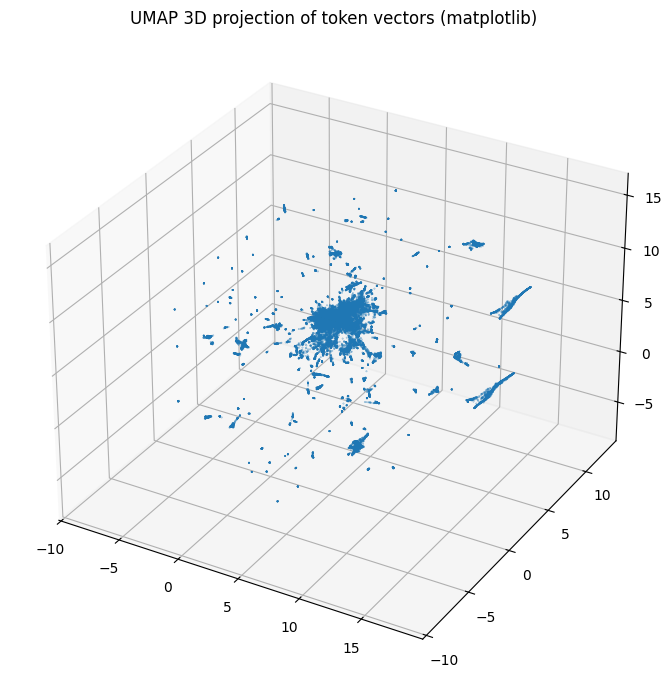

In [ ]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["x"],
    df["y"],
    df["z"],

    cmap="tab20",
    s=.1,
    alpha=0.6
)

ax.set_title("UMAP 3D projection of token vectors (matplotlib)")
plt.tight_layout()
plt.show()


Graficacion con k-means prueba 1

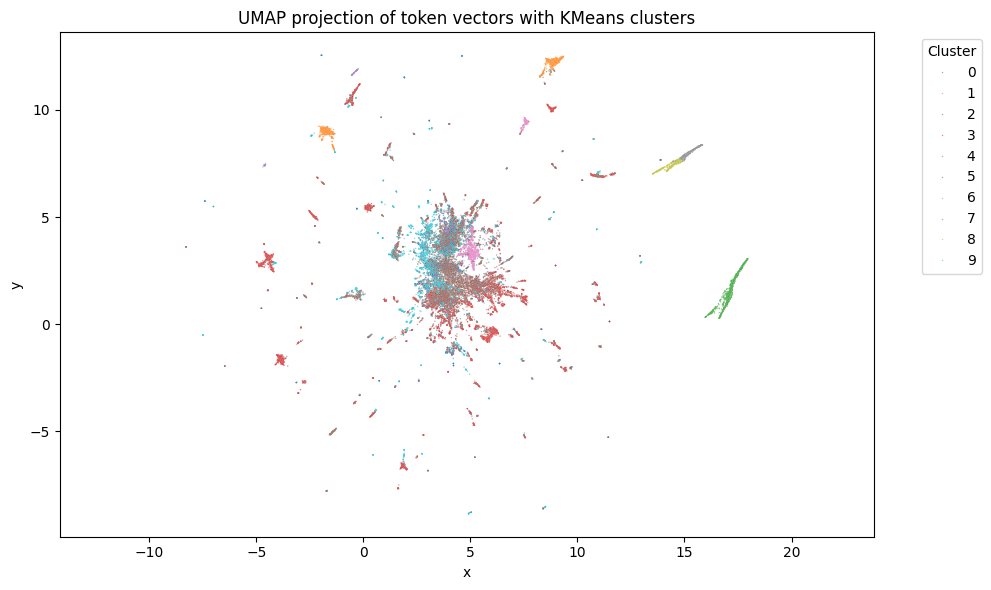

In [ ]:

from sklearn.cluster import KMeans
import seaborn as sns


# Aplicar KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Visualizar sobre UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df["x"],
    y=df["y"],
    hue=df["cluster"],
    palette="tab10",
    s=1,
    alpha=0.6,
    legend="full"
)
plt.title("UMAP projection of token vectors with KMeans clusters")
plt.gca().set_aspect("equal", "datalim")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Clusterización con DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [ ]:

from sklearn.preprocessing import StandardScaler

X_umap = df[["x", "y"]].values

eps = 0.1
db = DBSCAN(eps=eps, min_samples=7)
df["dbscan_cluster"] = db.fit_predict(X_umap)



In [ ]:
np.unique(np.array(df["dbscan_cluster"].to_list()),return_counts=True)

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
         12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176

In [ ]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="dbscan_cluster",
    title="DBSCAN clustering sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token","region","id_tweet"]
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=600)
fig.show()

In [ ]:
print("Número de Cústeres:", df["dbscan_cluster"].nunique())


Número de Cústeres: 922


Lista de en cuantas regiones aparece un token excluyendo anomalias(cluster -1)

In [ ]:

df_filtrado = df[df["dbscan_cluster"] != -1]


regiones_por_token = (
    df_filtrado.groupby("token")["region"]
    .nunique()
    .reset_index(name="num_regiones")
    .sort_values(by="num_regiones", ascending=True)
)


regiones_por_token


,token,num_regiones
4,!!!!!,1
5281,🧡,1
3131,dándole,1
3130,day,1
3129,das,1
...,...,...
4478,que,31
2518,[CLS],32
2520,_GEO,32
2519,[SEP],32


Lista de numero de token por cluster excluyendo anomalias (cluster -1)

In [ ]:

tokens_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["token"]
    .count()
    .reset_index(name="num_tokens")
    .sort_values(by="num_tokens", ascending=True)
)


tokens_por_cluster


,dbscan_cluster,num_tokens
711,711,3
909,909,4
625,625,6
917,917,6
889,889,6
...,...,...
0,0,463
62,62,491
14,14,519
26,26,535


In [ ]:

df_filtrado = df[df["dbscan_cluster"] != -1]


tokens_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["token"]
    .count()
    .reset_index(name="num_tokens")
)


regiones_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["region"]
    .nunique()
    .reset_index(name="num_regiones")
)

resumen_cluster = pd.merge(tokens_por_cluster, regiones_por_cluster, on="dbscan_cluster")

resumen_cluster = resumen_cluster.sort_values(by="num_tokens")
resumen_cluster = resumen_cluster.sort_values(by="num_regiones", ascending=True)
resumen_cluster[100:150]


,dbscan_cluster,num_tokens,num_regiones
880,880,7,4
881,881,7,4
878,878,7,4
582,582,7,4
842,842,7,4
844,844,7,4
854,854,7,4
408,408,17,4
543,543,17,4
516,516,12,4


In [ ]:

clusters_por_token = (
    df[df["dbscan_cluster"] != -1]
    .groupby("token")["dbscan_cluster"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
)

clusters_por_token["num_clusters"] = clusters_por_token["dbscan_cluster"].apply(len)
clusters_por_token.rename(columns={"dbscan_cluster": "clusters"}, inplace=True)


id_tweets_por_token = (
    df[df["dbscan_cluster"] != -1]
    .groupby("token")["id_tweet"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
)


clusters_por_token = clusters_por_token.merge(id_tweets_por_token, on="token")


clusters_por_token = clusters_por_token.sort_values(by="num_clusters", ascending=True)


clusters_por_token



,token,clusters,num_clusters,id_tweet
3287,dudo,[9],1,[491]
3298,durmiendo,[628],1,"[212, 693]"
3297,durm,[445],1,"[592, 724]"
3295,dur,[18],1,[394]
3294,dulces,[866],1,[778]
...,...,...,...,...
2521,_URL,"[9, 60, 78, 117, 126, 195, 287, 288, 307, 326,...",15,"[3, 4, 7, 8, 10, 13, 16, 18, 21, 26, 27, 28, 3..."
2519,[SEP],"[26, 50, 134, 184, 196, 213, 298, 373, 526, 64...",15,"[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14..."
3820,la,"[83, 115, 156, 164, 182, 328, 383, 440, 464, 4...",17,"[5, 6, 7, 11, 14, 21, 22, 26, 27, 32, 34, 46, ..."
2520,_GEO,"[28, 42, 51, 62, 301, 309, 338, 381, 403, 551,...",19,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16..."


In [ ]:
clusters_por_token[clusters_por_token["num_clusters"] == 2][100:150]

,token,clusters,num_clusters,id_tweet
5239,🙃,"[9, 720]",2,"[753, 915]"
3656,haciendo,"[385, 424]",2,"[43, 122, 176, 214, 287, 562, 637, 905]"
4791,suerte,"[264, 813]",2,"[251, 639]"
2082,ME,"[9, 505]",2,"[285, 590, 930]"
1573,11,"[65, 358]",2,"[42, 101, 540]"
3389,equipo,"[74, 369]",2,"[4, 271, 482, 557, 772, 872]"
4626,ruido,"[165, 638]",2,"[546, 552]"
17,##!!,"[413, 665]",2,"[831, 870]"
483,##cl,"[9, 849]",2,"[66, 257, 481]"
4628,s,"[59, 82]",2,"[14, 164]"


In [ ]:
mostrar_tweets_completos(df, ids_buscados=[55, 105, 150, 178, 320, 378])


Tweet (id_tweet=55):
[CLS] Mexico_City _GEO Ya tienen listos sus calz ##on ##citos para el espacio de esta noche … ##?! ##?! 🍆 ##🩲 ##💧 Habrá más # conf ##ex ##xx ##iones en calzones ? Quien sabe ! Todo puede pasar , va ##ti ##tos ! [SEP]
--------------------------------------------------

Tweet (id_tweet=105):
[CLS] NL _GEO _USR No es su tiempo y él lo sabe . [SEP]
--------------------------------------------------

Tweet (id_tweet=150):
[CLS] NL _GEO _USR El pá ##jar ##o vio el cielo y se vol ##ó es la # 1 se sabe [SEP]
--------------------------------------------------

Tweet (id_tweet=178):
[CLS] Coahuila _GEO La médico general que no sabe su ##tura ##r : Deberían traer a los res ##identes para eso están . Mi ##ja que no le sepas no significa que te tengan que hacer el jal ##e [SEP]
--------------------------------------------------

Tweet (id_tweet=320):
[CLS] QR _GEO _USR Mi papá ya hace mucho falle ##ció y así lo toma ##ban en los 70 ' s , suena raro , pero sabe bien 

Lista de cuantos cluster tiene cada region

In [ ]:

clusters_por_region = (
    df.groupby("region")["dbscan_cluster"]
    .nunique()
    .reset_index(name="num_clusters_unicos")
    .sort_values(by="num_clusters_unicos", ascending=False)
)

clusters_por_region


,region,num_clusters_unicos
14,Mexico_City,795
17,NL,650
12,Jalisco,548
1,BC,516
13,Mexico,509
25,Sonora,448
29,Veracruz,412
5,Chihuahua,352
24,Sinaloa,342
20,Puebla,318


Lista de todos los tokens y en que cluster se encuentra

In [ ]:
tabla_tokens = df[["token", "region", "dbscan_cluster"]].sort_values( by=["token","dbscan_cluster"])
excel_filename = f"tabla_tokens.xlsx"
tabla_tokens.to_excel(excel_filename, index=False)
tabla_tokens

,token,region,dbscan_cluster
416,!,NL,193
1584,!,Mexico_City,193
1592,!,Mexico_City,193
1824,!,Mexico_City,193
1839,!,Mexico_City,193
...,...,...,...
2936,🦠,Zacatecas,287
10641,🧐,Tabasco,444
14259,🧡,Sonora,191
25422,🩹,QR,248


Mostrar cluster en especifico

In [ ]:

cluster_id = 523
tokens_cluster = df[df["dbscan_cluster"] == cluster_id][["token", "region", "dbscan_cluster","id_tweet"]]

tokens_cluster = tokens_cluster.sort_values(by="token")

tokens_cluster


,token,region,dbscan_cluster,id_tweet
17811,##DA,NL,523,590
2109,##RA,NL,523,70
5614,##RA,BC,523,175
10035,##RA,Mexico,523,325
20583,##RA,Mexico,523,678
20587,##RA,Mexico,523,678
28387,##RA,Mexico_City,523,930
6086,##RO,Guanajuato,523,191
8751,##RO,Mexico_City,523,285
10998,##ra,Mexico_City,523,355


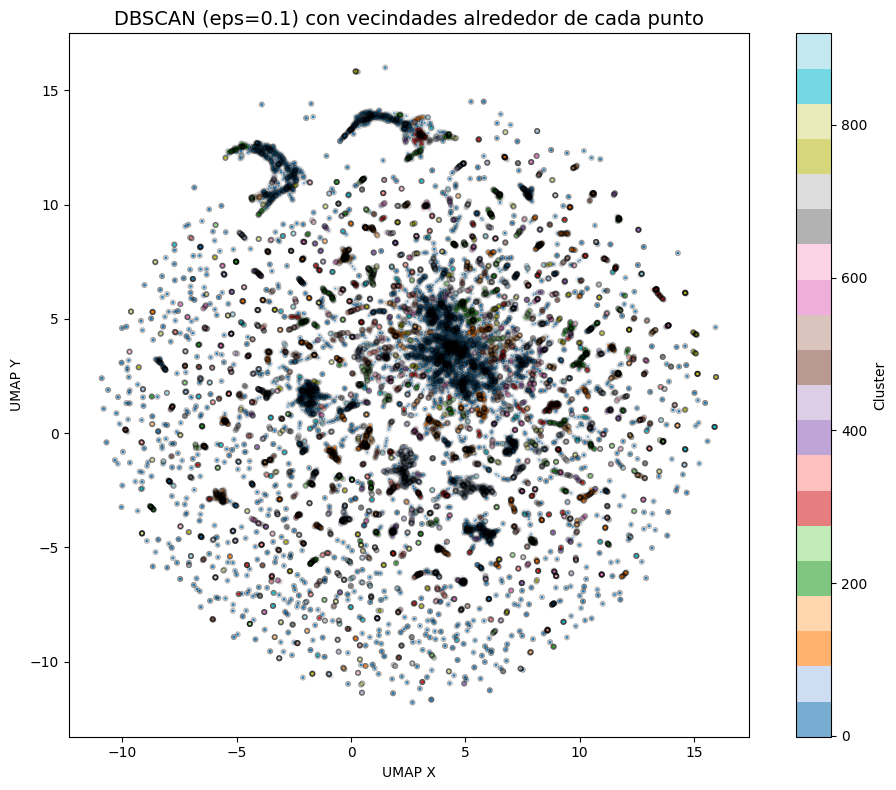

In [ ]:
plt.figure(figsize=(10, 8))

# Puntos coloreados por clúster
scatter = plt.scatter(
    df["x"], df["y"],
    c=df["dbscan_cluster"],
    cmap="tab20",
    s=.5,
    alpha=0.6
)

# Dibujar un círculo eps alrededor de cada punto
for x, y in X_umap:
    circle = plt.Circle((x, y), eps, color='black', fill=False, alpha=0.1)
    plt.gca().add_patch(circle)

plt.gca().set_aspect("equal", "box")
plt.title(f"DBSCAN (eps={eps}) con vecindades alrededor de cada punto", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()



Clusterización con HDBSCAN

In [ ]:
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [ ]:
clusterer = HDBSCAN(min_cluster_size=9)
cluster_labels = clusterer.fit_predict(X_umap)

df["hdbscan_cluster"] = cluster_labels

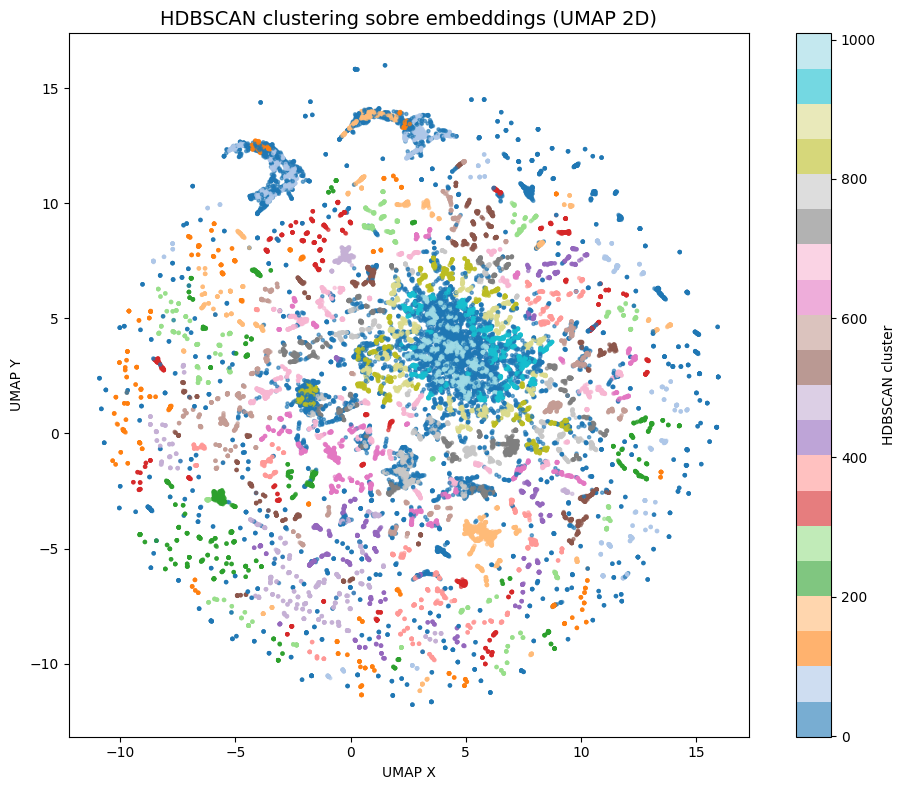

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["x"],
    df["y"],
    c=df["hdbscan_cluster"],
    cmap="tab20",
    s=5,
    alpha=0.6
)
plt.colorbar(scatter, label="HDBSCAN cluster")
plt.title("HDBSCAN clustering sobre embeddings (UMAP 2D)", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


In [ ]:
print("Número de Cústeres:", df["hdbscan_cluster"].nunique())


Número de Cústeres: 1011


In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="hdbscan_cluster",
    title="Clustering con HDBSCAN sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token", "region","id_tweet"]
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()


In [ ]:

cluster_id = 93
tokens_cluster = df[df["hdbscan_cluster"] == cluster_id][["token", "region", "hdbscan_cluster","id_tweet"]]

tokens_cluster = tokens_cluster.sort_values(by="token")

tokens_cluster

,token,region,hdbscan_cluster,id_tweet
16172,[SEP],Puebla,93,539
25613,[SEP],Campeche,93,844
5609,[SEP],Michoacán,93,174
26774,contra,Mexico_City,93,881
26899,contra,Mexico_City,93,884
11944,contra,Puebla,93,394
30178,contra,Mexico,93,994
7312,contra,NL,93,233
26160,favor,Colima,93,861
5002,q,Jalisco,93,158


In [ ]:
def mostrar_tweets_completos(df, ids_buscados):
    for id_buscado in ids_buscados:
        tweet = df[df["id_tweet"] == id_buscado].sort_values(by="id_vector")
        texto_tweet = " ".join(tweet["token"].tolist())
        print(f"\nTweet (id_tweet={id_buscado}):\n{texto_tweet}\n" + "-"*50)



In [ ]:
mostrar_tweets_completos(df, ids_buscados=[245, 697])


Tweet (id_tweet=245):
[CLS] Querétaro _GEO Ahora que mis amigas andan sol ##teras necesitamos una salida al antro 🎉 [SEP]
--------------------------------------------------

Tweet (id_tweet=697):
[CLS] Puebla _GEO De 💯 ojalá nos uni ##remos con U ##d muchos pero millones que necesitamos que este retro ##ceso nos va llevar al caos con este # AMLO ##En ##fer ##mo ##Me ##n ##tal [SEP]
--------------------------------------------------
